# 09 — Interpretable description of HH regions

**Goal:** Analyze **LISA High–High (HH)** hotspots using shallow decision trees for interpretable rules.

**Two levels of analysis:**
1. **Global**: HH-vs-non-HH rules across all test samples
2. **Component**: Individual HH connected components analyzed one-vs-rest

**Outputs:** Tables in `thesis_outputs/tables/nb09/`, figures in `thesis_outputs/figures/nb09/`.

All rule learning uses **raw/readable features** (age in years, counts, etc.), not scaled versions.


In [1]:
import sys
from pathlib import Path
import warnings

warnings.filterwarnings("ignore", category=UserWarning)

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

from thesis_layout import RAW_RESULTS, thesis_output_dirs

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import sparse
from sklearn.decomposition import PCA

# Data and preprocessing
from data import load_dataset, make_preprocessor
from analysis.run_analysis import load_split, run_spatial
from analysis.preprocessing import get_transformed_test_features
from analysis.knn_defaults import default_k_nn
from analysis.spatial import extract_hh_components

# Interpretable rules module
from analysis.nb09_interpretable_rules import (
    get_raw_test_features,
    analyze_hh_global,
    analyze_component,
    concat_with_seed,
    recurring_rules_by_method_label,
    rule_feature_frequency_across_seeds,
)

RESULTS_DIR = RAW_RESULTS
TABLE_DIR, FIG_DIR = thesis_output_dirs("nb09")

print(f"Results directory: {RESULTS_DIR}")
print(f"Tables output to: {TABLE_DIR}")
print(f"Figures output to: {FIG_DIR}")


Results directory: C:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\results
Tables output to: C:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\thesis_outputs\tables\nb09
Figures output to: C:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\thesis_outputs\figures\nb09


## Configuration

Analysis parameters: seed range, dataset, tree hyperparameters, component size thresholds.


In [2]:
# Analysis parameters
OUTER_SEEDS = list(range(10))
SEED_FOR_FIGURES = 0
dataset_name = "compas"
K = 25  # Rashomon set size

# Tree hyperparameters
TREE_MAX_DEPTH = 3
TREE_MIN_SAMPLES_LEAF_GLOBAL = 10
TREE_MIN_SAMPLES_LEAF_COMPONENT = 5

# Component filtering
MIN_COMPONENT_SIZE = 20

# Bootstrap and permutation parameters
N_BOOTSTRAP_OOB = 200
N_PERMUTATIONS = 500

print(f"Dataset: {dataset_name}")
print(f"Outer seeds: {OUTER_SEEDS}")
print(f"Min component size: {MIN_COMPONENT_SIZE}")
print(f"Trees: max_depth={TREE_MAX_DEPTH}, min_samples_leaf (global)={TREE_MIN_SAMPLES_LEAF_GLOBAL}, (component)={TREE_MIN_SAMPLES_LEAF_COMPONENT}")


Dataset: compas
Outer seeds: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Min component size: 20
Trees: max_depth=3, min_samples_leaf (global)=10, (component)=5


## Helper functions

Load raw test features, spatial data, and components.


In [3]:
def load_seed_data(run_dir: Path, dataset_name: str, K: int = 25, seed: int = 42) -> dict:
    """
    Load all data for a seed:
    - raw test features (for rule learning)
    - spatial result (HH mask, W, etc.)
    - HH components
    
    Returns dict with:
        - X_raw, feature_names, HH_mask, W, components, component_ids
    """
    run_dir = Path(run_dir)
    if not run_dir.is_dir():
        raise FileNotFoundError(f"Missing results directory: {run_dir}")
    
    # Load raw features
    X_raw, feature_names = get_raw_test_features(run_dir, dataset_name)
    n_test = len(X_raw)
    
    # Load spatial result
    split = load_split(run_dir)
    X_transformed = get_transformed_test_features(run_dir, dataset_name)
    k_nn = default_k_nn(dataset_name)
    spatial = run_spatial(run_dir, X_transformed, K=K, k=k_nn, seed=seed)
    
    HH_mask = spatial["HH_mask"]
    W = spatial.get("W")
    
    # Extract HH components
    lisa_df = pd.DataFrame({"cluster": np.where(HH_mask, "HH", "NS")})
    
    if W is not None:
        if not isinstance(W, sparse.csr_matrix):
            if hasattr(W, "sparse"):
                W = W.sparse
            elif hasattr(W, "to_sparse"):
                W = W.to_sparse()
            else:
                W = sparse.csr_matrix(W)
        comp_id, components = extract_hh_components(lisa_df, W, min_size=5)
    else:
        comp_id, components = np.full(n_test, -1), {}
    
    # Filter to components with size >= MIN_COMPONENT_SIZE
    components_kept = {
        cid: idx for cid, idx in components.items()
        if len(idx) >= MIN_COMPONENT_SIZE
    }
    
    return {
        "X_raw": X_raw,
        "feature_names": feature_names,
        "X_transformed": X_transformed,
        "HH_mask": np.asarray(HH_mask, dtype=bool),
        "W": W,
        "comp_id": comp_id,
        "components_all": components,
        "components_kept": components_kept,
        "n_test": n_test,
    }

print("Helper functions defined")

Helper functions defined


## Global HH-vs-non-HH rules across seeds

For each seed: fit decision tree on raw features to distinguish HH from non-HH.
Extract positive-leaf rules with support, purity, recall, lift metrics.


In [4]:
# Run global HH-vs-non-HH analysis for all seeds
global_rules_by_seed = []
global_metadata_by_seed = {}
seeds_completed = []
plot_bundle = None

for SEED in OUTER_SEEDS:
    run_dir = RESULTS_DIR / dataset_name / f"seed={SEED}"
    if not run_dir.is_dir():
        print(f"[skip] {SEED}: missing {run_dir}")
        continue
    
    try:
        data = load_seed_data(run_dir, dataset_name, K=K, seed=SEED)
    except Exception as e:
        print(f"[error] {SEED}: {e}")
        continue
    
    X_raw = data["X_raw"]
    feature_names = data["feature_names"]
    HH_mask = data["HH_mask"]
    
    # Analyze global HH
    rules_df, metadata = analyze_hh_global(
        X_raw, HH_mask, feature_names,
        max_depth=TREE_MAX_DEPTH,
        min_samples_leaf=TREE_MIN_SAMPLES_LEAF_GLOBAL,
        seed=42,
    )
    
    rules_df["outer_seed"] = SEED
    global_rules_by_seed.append(rules_df)
    global_metadata_by_seed[SEED] = metadata
    seeds_completed.append(SEED)
    
    # Store data for figures
    if SEED == SEED_FOR_FIGURES:
        plot_bundle = {
            "seed": SEED,
            "X_raw": X_raw,
            "feature_names": feature_names,
            "HH_mask": HH_mask,
            "W": data["W"],
            "components_all": data["components_all"],
            "components_kept": data["components_kept"],
            "X_transformed": data["X_transformed"],
        }
    
    print(f"[seed {SEED}] n_test={len(X_raw)}, n_hh={HH_mask.sum()}, rules={len(rules_df)}")

if not seeds_completed:
    raise RuntimeError(f"No seeds completed. Check {RESULTS_DIR}/{dataset_name}/ for seed=* directories.")

global_rules_all = concat_with_seed(global_rules_by_seed, seeds_completed)
print(f"\nCompleted {len(seeds_completed)} seeds: {seeds_completed}")
print(f"Global rules table: {len(global_rules_all)} rows")


[seed 0] n_test=1443, n_hh=48, rules=5


[seed 1] n_test=1443, n_hh=112, rules=4


[seed 2] n_test=1443, n_hh=54, rules=4


[seed 3] n_test=1443, n_hh=167, rules=8


[seed 4] n_test=1443, n_hh=21, rules=3


[seed 5] n_test=1443, n_hh=50, rules=5


[seed 6] n_test=1443, n_hh=100, rules=7


[seed 7] n_test=1443, n_hh=112, rules=5


[seed 8] n_test=1443, n_hh=138, rules=5


[seed 9] n_test=1443, n_hh=22, rules=3

Completed 10 seeds: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Global rules table: 49 rows


## Component-level HH rules across seeds

For each seed and each HH component with size >= MIN_COMPONENT_SIZE:
- Fit tree to distinguish component (positive) from non-component (negative)
- Extract positive-leaf rules with support, component_purity, component_recall, etc.
- Compute mean pointwise variance within and outside component


In [5]:
# Run component-level analysis for all seeds
component_rules_by_seed = []
component_summary_by_seed = []

for SEED in seeds_completed:
    run_dir = RESULTS_DIR / dataset_name / f"seed={SEED}"
    data = load_seed_data(run_dir, dataset_name, K=K, seed=SEED)
    
    X_raw = data["X_raw"]
    feature_names = data["feature_names"]
    HH_mask = data["HH_mask"]
    components_kept = data["components_kept"]
    n_test = data["n_test"]
    n_hh = HH_mask.sum()
    
    # Analyze all sufficiently large HH components
    components_to_analyze = sorted(
        components_kept.items(),
        key=lambda x: len(x[1]),
        reverse=True,
    )
    for comp_rank, (comp_id, comp_indices) in enumerate(components_to_analyze):
        component_mask = np.zeros(n_test, dtype=bool)
        component_mask[comp_indices] = True
        comp_size = len(comp_indices)
        
        rules_df, metadata = analyze_component(
            X_raw, feature_names, component_mask, comp_size, HH_mask,
            max_depth=TREE_MAX_DEPTH,
            min_samples_leaf=TREE_MIN_SAMPLES_LEAF_COMPONENT,
            seed=42,
        )
        
        if rules_df is not None and len(rules_df) > 0:
            rules_df["outer_seed"] = SEED
            rules_df["component_id"] = comp_id
            rules_df["component_rank_by_size"] = comp_rank + 1
            rules_df["component_size"] = comp_size
            rules_df["component_share_of_hh"] = comp_size / n_hh if n_hh > 0 else 0.0
            rules_df["n_hh_total"] = n_hh
            rules_df["n_test"] = n_test
            
            component_rules_by_seed.append(rules_df)
        
        # Component summary
        comp_summary = {
            "outer_seed": SEED,
            "n_test": n_test,
            "n_hh_total": n_hh,
            "hh_rate": n_hh / n_test if n_test > 0 else 0.0,
            "n_components_all": len(data["components_all"]),
            "n_components_kept": len(components_kept),
            "min_component_size": MIN_COMPONENT_SIZE,
            "component_id": comp_id,
            "component_rank_by_size": comp_rank + 1,
            "component_size": comp_size,
            "component_share_of_hh": comp_size / n_hh if n_hh > 0 else 0.0,
        }
        component_summary_by_seed.append(comp_summary)
    
    print(f"[seed {SEED}] {len(components_kept)} components kept (of {len(data['components_all'])} total)")

if component_rules_by_seed:
    component_rules_all = pd.concat(component_rules_by_seed, ignore_index=True)
else:
    component_rules_all = pd.DataFrame()

component_summary_all = pd.DataFrame(component_summary_by_seed)

print(f"Component rules: {len(component_rules_all)} rows")
print(f"Component summaries: {len(component_summary_all)} rows")


[seed 0] 1 components kept (of 1 total)


[seed 1] 2 components kept (of 7 total)


[seed 2] 1 components kept (of 3 total)


[seed 3] 5 components kept (of 5 total)


[seed 4] 0 components kept (of 2 total)


[seed 5] 1 components kept (of 3 total)


[seed 6] 2 components kept (of 6 total)


[seed 7] 2 components kept (of 5 total)


[seed 8] 3 components kept (of 3 total)


[seed 9] 0 components kept (of 2 total)
Component rules: 36 rows
Component summaries: 17 rows


## Minimal thesis-ready figures

1. Global HH-vs-non-HH rules: support vs purity
2. Component rules: support vs component_purity
3. PCA with HH components (representative seed)


Saved: rules_support_purity_compas.pdf


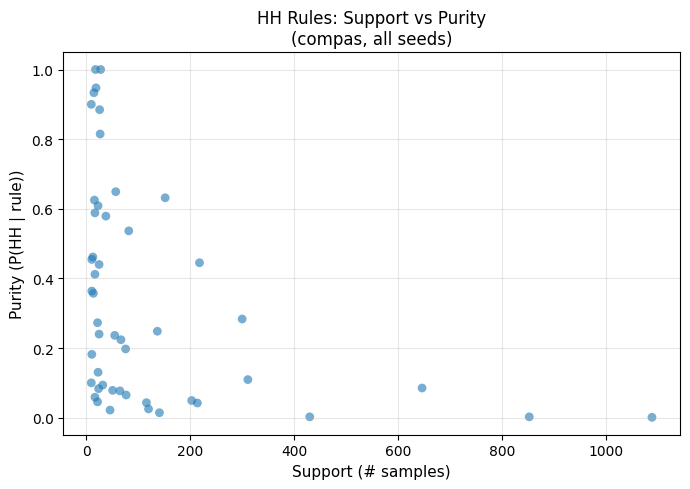

In [6]:
# Figure 1: Global HH rules - support vs purity
df_global = global_rules_all.dropna(subset=["support", "purity"])

fig, ax = plt.subplots(figsize=(7, 5))
scatter = ax.scatter(
    df_global["support"],
    df_global["purity"],
    alpha=0.6,
    s=40,
    edgecolors="none",
)
ax.set_xlabel("Support (# samples)", fontsize=11)
ax.set_ylabel("Purity (P(HH | rule))", fontsize=11)
ax.set_title(f"HH Rules: Support vs Purity\n({dataset_name}, all seeds)", fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / f"rules_support_purity_{dataset_name}.pdf", dpi=300, bbox_inches='tight')
print(f"Saved: rules_support_purity_{dataset_name}.pdf")
plt.show()


Saved: component_rules_support_purity_compas.pdf


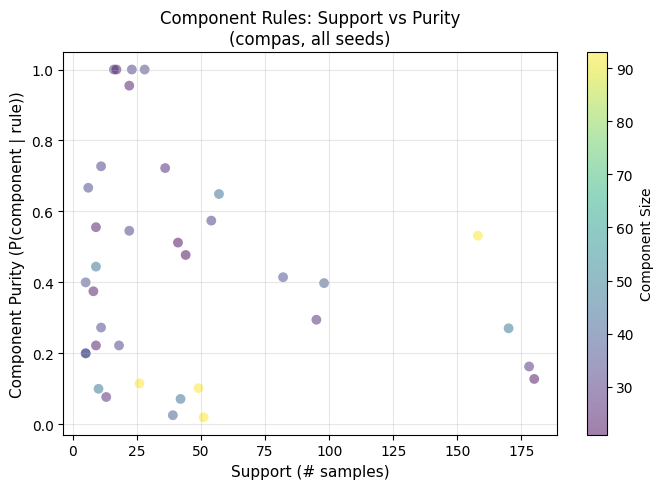

In [7]:
# Figure 2: Component rules - support vs component_purity
if len(component_rules_all) > 0:
    df_comp = component_rules_all.dropna(subset=["support", "component_purity"])
    
    fig, ax = plt.subplots(figsize=(7, 5))
    scatter = ax.scatter(
        df_comp["support"],
        df_comp["component_purity"],
        s=50,
        alpha=0.5,
        c=df_comp.get("component_size", 20),
        cmap="viridis",
        edgecolors="none",
    )
    ax.set_xlabel("Support (# samples)", fontsize=11)
    ax.set_ylabel("Component Purity (P(component | rule))", fontsize=11)
    ax.set_title(f"Component Rules: Support vs Purity\n({dataset_name}, all seeds)", fontsize=12)
    cbar = plt.colorbar(scatter, ax=ax, label="Component Size")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"component_rules_support_purity_{dataset_name}.pdf", dpi=300, bbox_inches='tight')
    print(f"Saved: component_rules_support_purity_{dataset_name}.pdf")
    plt.show()
else:
    print("No component rules to plot")


Saved: pca_hh_components_compas_seed0.pdf


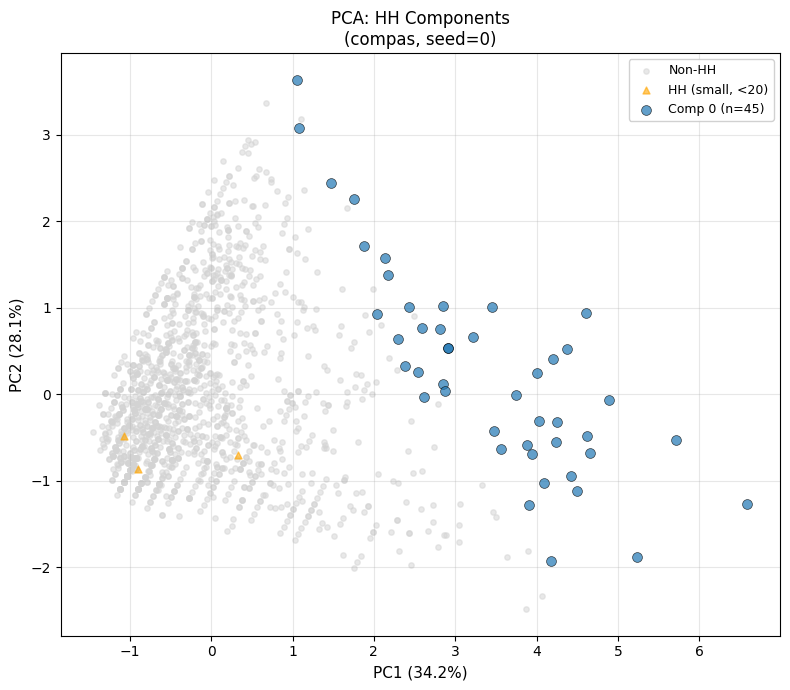

In [8]:
# Figure 3: PCA with HH components (representative seed)
if plot_bundle is None:
    print("No plot_bundle available for figures")
else:
    pb = plot_bundle
    X_raw = pb["X_raw"]
    X_transformed = pb["X_transformed"]
    HH_mask = pb["HH_mask"]
    components_kept = pb["components_kept"]
    
    # PCA on transformed features
    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X_transformed)
    
    fig, ax = plt.subplots(figsize=(8, 7))
    
    # Background: all non-HH
    ax.scatter(
        X_pca[~HH_mask, 0],
        X_pca[~HH_mask, 1],
        c="lightgray",
        s=15,
        alpha=0.5,
        label="Non-HH",
        zorder=1,
    )
    
    # HH non-component (small or < MIN_COMPONENT_SIZE)
    all_hh_idx = np.where(HH_mask)[0]
    small_hh = []
    for idx in all_hh_idx:
        in_kept = False
        for comp_indices in components_kept.values():
            if idx in comp_indices:
                in_kept = True
                break
        if not in_kept:
            small_hh.append(idx)
    
    if small_hh:
        ax.scatter(
            X_pca[small_hh, 0],
            X_pca[small_hh, 1],
            c="orange",
            s=25,
            alpha=0.6,
            marker="^",
            label=f"HH (small, <{MIN_COMPONENT_SIZE})",
            zorder=2,
        )
    
    # Kept components (different colors)
    colors = plt.cm.tab10(np.linspace(0, 1, min(10, len(components_kept))))
    for color_idx, (comp_id, comp_indices) in enumerate(sorted(
        components_kept.items(),
        key=lambda x: len(x[1]),
        reverse=True
    )[:10]):
        ax.scatter(
            X_pca[comp_indices, 0],
            X_pca[comp_indices, 1],
            c=[colors[color_idx]],
            s=50,
            alpha=0.7,
            label=f"Comp {comp_id} (n={len(comp_indices)})",
            edgecolors="black",
            linewidth=0.5,
            zorder=3,
        )
    
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})", fontsize=11)
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})", fontsize=11)
    ax.set_title(f"PCA: HH Components\n({dataset_name}, seed={pb['seed']})", fontsize=12)
    ax.legend(loc="best", fontsize=9, framealpha=0.9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"pca_hh_components_{dataset_name}_seed{pb['seed']}.pdf", dpi=300, bbox_inches='tight')
    print(f"Saved: pca_hh_components_{dataset_name}_seed{pb['seed']}.pdf")
    plt.show()


## Feature frequency and recurring rules

Identify features that frequently appear across seeds and rules.


In [9]:
# Compute global rule feature frequency
global_feature_freq = rule_feature_frequency_across_seeds(
    global_rules_all,
    last_feature_names := global_metadata_by_seed[seeds_completed[0]].get("feature_names", []),
)

# Compute recurring rules (appear in multiple seeds)
global_recurring = recurring_rules_by_method_label(global_rules_all, min_seeds=3)

# Component feature frequency
if len(component_rules_all) > 0:
    comp_feature_freq = rule_feature_frequency_across_seeds(
        component_rules_all,
        last_feature_names,
    )
else:
    comp_feature_freq = pd.DataFrame()

print(f"Global feature frequency: {len(global_feature_freq)} distinct features")
print(f"Global recurring rules (in >=3 seeds): {len(global_recurring)}")
print(f"Component feature frequency: {len(comp_feature_freq)} distinct features")


Global feature frequency: 9 distinct features
Global recurring rules (in >=3 seeds): 0
Component feature frequency: 11 distinct features


Plotting raw feature region for age and priors_count


Saved: rule_region_age_priors_compas.pdf


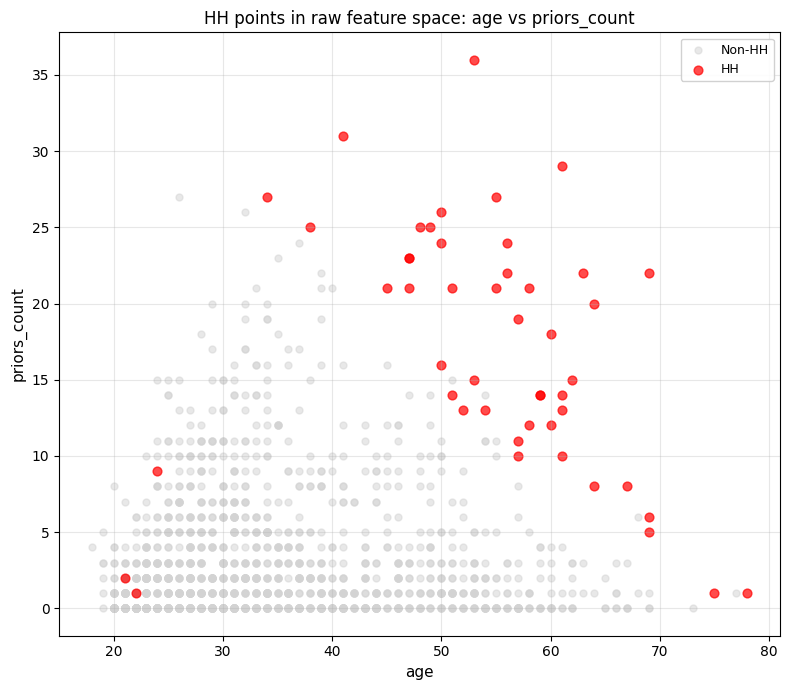

In [10]:
import matplotlib.patches as patches

# Figure 4: Raw feature-space visualization for top rule features
if len(global_feature_freq) == 0:
    print("No frequent rule features available for raw feature visualization")
else:
    top_features = global_feature_freq["feature"].tolist()
    if "age" in top_features and "priors_count" in top_features:
        x_feature, y_feature = "age", "priors_count"
    elif len(top_features) >= 2:
        x_feature, y_feature = top_features[:2]
    else:
        print("Not enough frequent rule features to plot")
        x_feature = y_feature = None

    if x_feature is None or y_feature is None:
        pass
    else:
        print(f"Plotting raw feature region for {x_feature} and {y_feature}")

        if plot_bundle is None:
            print("No representative seed data available for raw feature plot")
        else:
            X_raw = plot_bundle["X_raw"]
            HH_mask = plot_bundle["HH_mask"]
            df_plot = X_raw[[x_feature, y_feature]].copy()
            df_plot["HH"] = HH_mask

            fig, ax = plt.subplots(figsize=(8, 7))
            ax.scatter(
                df_plot.loc[~df_plot["HH"], x_feature],
                df_plot.loc[~df_plot["HH"], y_feature],
                c="lightgray",
                s=25,
                alpha=0.5,
                label="Non-HH",
            )
            ax.scatter(
                df_plot.loc[df_plot["HH"], x_feature],
                df_plot.loc[df_plot["HH"], y_feature],
                c="red",
                s=40,
                alpha=0.7,
                label="HH",
            )

            anno_rule = None
            for _, rule in global_rules_all.iterrows():
                if x_feature in str(rule.get("rule_features", "")) and y_feature in str(rule.get("rule_features", "")):
                    anno_rule = str(rule["rule_text"])
                    break

            if anno_rule is not None and " AND " in anno_rule:
                bounds = {x_feature: [None, None], y_feature: [None, None]}
                for term in anno_rule.split(" AND "):
                    if term.startswith(f"{x_feature} <="):
                        bounds[x_feature][1] = float(term.split("<=")[1].strip())
                    elif term.startswith(f"{x_feature} >"):
                        bounds[x_feature][0] = float(term.split(">")[1].strip())
                    elif term.startswith(f"{y_feature} <="):
                        bounds[y_feature][1] = float(term.split("<=")[1].strip())
                    elif term.startswith(f"{y_feature} >"):
                        bounds[y_feature][0] = float(term.split(">")[1].strip())

                if all(v is not None for v in [bounds[x_feature][0], bounds[x_feature][1], bounds[y_feature][0], bounds[y_feature][1]]):
                    rect = patches.Rectangle(
                        (bounds[x_feature][0], bounds[y_feature][0]),
                        bounds[x_feature][1] - bounds[x_feature][0],
                        bounds[y_feature][1] - bounds[y_feature][0],
                        linewidth=2,
                        edgecolor="blue",
                        facecolor="none",
                        linestyle="--",
                        label=f"Rule region: {anno_rule}",
                    )
                    ax.add_patch(rect)

            ax.set_xlabel(x_feature, fontsize=11)
            ax.set_ylabel(y_feature, fontsize=11)
            ax.set_title(f"HH points in raw feature space: {x_feature} vs {y_feature}", fontsize=12)
            ax.legend(loc="best", fontsize=9, framealpha=0.9)
            ax.grid(True, alpha=0.3)
            plt.tight_layout()
            if x_feature == 'age' and y_feature == 'priors_count':
                output_name = f"rule_region_age_priors_{dataset_name}.pdf"
            else:
                output_name = f"rule_region_{x_feature}_{y_feature}_{dataset_name}.pdf"
            plt.savefig(FIG_DIR / output_name, dpi=300, bbox_inches='tight')
            print(f"Saved: {output_name}")
            plt.show()

In [11]:
# Export all tables

# Ensure output directories exist
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Global rules tables
print("Saving global rules tables...")
global_rules_all.to_csv(TABLE_DIR / f"rules_summary_{dataset_name}.csv", index=False)
global_feature_freq.to_csv(TABLE_DIR / f"rule_feature_frequency_{dataset_name}.csv", index=False)
global_recurring.to_csv(TABLE_DIR / f"rules_recurring_across_seeds_{dataset_name}.csv", index=False)

# Component-level tables
print("Saving component tables...")
if len(component_rules_all) > 0:
    component_rules_all.to_csv(TABLE_DIR / f"component_rules_summary_{dataset_name}.csv", index=False)
    comp_feature_freq.to_csv(TABLE_DIR / f"component_feature_frequency_{dataset_name}.csv", index=False)
    component_summary_all.to_csv(TABLE_DIR / f"component_summary_{dataset_name}.csv", index=False)

print(f"\n✓ Tables saved to {TABLE_DIR}")
print(f"✓ Figures saved to {FIG_DIR}")

# Summary statistics
print(f"\nExport Summary:")
print(f"  Global rules: {len(global_rules_all)} rows")
print(f"  Component rules: {len(component_rules_all)} rows")
print(f"  Component summaries: {len(component_summary_all)} rows")
print(f"  Seeds completed: {len(seeds_completed)}")


Saving global rules tables...
Saving component tables...

✓ Tables saved to C:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\thesis_outputs\tables\nb09
✓ Figures saved to C:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\thesis_outputs\figures\nb09

Export Summary:
  Global rules: 49 rows
  Component rules: 36 rows
  Component summaries: 17 rows
  Seeds completed: 10


## Sanity checks

Validate outputs and check for completeness.


In [12]:
# Sanity checks
print("=== SANITY CHECKS ===\n")

# Check 1: Completed seeds
print(f"✓ Completed seeds: {seeds_completed}")
assert len(seeds_completed) > 0, "No seeds completed!"
print(f"  Expected: 10, Actual: {len(seeds_completed)}\n")

# Check 2: HH counts per seed
print(f"✓ HH point counts per seed:")
for seed in seeds_completed:
    n_hh = global_metadata_by_seed[seed]["n_hh"]
    n_total = global_metadata_by_seed[seed]["n_total"]
    print(f"  Seed {seed}: {n_hh}/{n_total} HH points ({100*n_hh/n_total:.1f}%)")
print()

# Check 3: Component analysis
print(f"✓ Component statistics:")
for seed in seeds_completed:
    run_dir = RESULTS_DIR / dataset_name / f"seed={seed}"
    data = load_seed_data(run_dir, dataset_name, K=K, seed=seed)
    n_all = len(data["components_all"])
    n_kept = len(data["components_kept"])
    print(f"  Seed {seed}: {n_kept} kept components (of {n_all} total, min_size={MIN_COMPONENT_SIZE})")
print()

# Check 4: Table column presence
print(f"✓ Required columns check:")
required_global = ["outer_seed", "rule_text", "support", "purity"]
for col in required_global:
    assert col in global_rules_all.columns or col in global_rules_all.columns.str.lower(), f"Missing global column: {col}"
print(f"  Global rules table: OK ({', '.join(required_global)})")

if len(component_rules_all) > 0:
    required_comp = ["outer_seed", "component_id", "component_size", "support"]
    for col in required_comp:
        assert col in component_rules_all.columns, f"Missing component column: {col}"
    print(f"  Component rules table: OK ({', '.join(required_comp)})")
print()

# Check 5: Files exist
print(f"✓ Output files check:")
files_to_check = [
    TABLE_DIR / f"rules_summary_{dataset_name}.csv",
    TABLE_DIR / f"rule_feature_frequency_{dataset_name}.csv",
    FIG_DIR / f"rules_support_purity_{dataset_name}.pdf",
]
if len(component_rules_all) > 0:
    files_to_check.extend([
        TABLE_DIR / f"component_rules_summary_{dataset_name}.csv",
        TABLE_DIR / f"component_summary_{dataset_name}.csv",
    ])

for fpath in files_to_check:
    exists = "✓" if fpath.exists() else "✗"
    print(f"  {exists} {fpath.name}")

print("\n✓ All sanity checks passed! Notebook ready for thesis.")


=== SANITY CHECKS ===

✓ Completed seeds: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
  Expected: 10, Actual: 10

✓ HH point counts per seed:
  Seed 0: 48/1443 HH points (3.3%)
  Seed 1: 112/1443 HH points (7.8%)
  Seed 2: 54/1443 HH points (3.7%)
  Seed 3: 167/1443 HH points (11.6%)
  Seed 4: 21/1443 HH points (1.5%)
  Seed 5: 50/1443 HH points (3.5%)
  Seed 6: 100/1443 HH points (6.9%)
  Seed 7: 112/1443 HH points (7.8%)
  Seed 8: 138/1443 HH points (9.6%)
  Seed 9: 22/1443 HH points (1.5%)

✓ Component statistics:


  Seed 0: 1 kept components (of 1 total, min_size=20)


  Seed 1: 2 kept components (of 7 total, min_size=20)


  Seed 2: 1 kept components (of 3 total, min_size=20)


  Seed 3: 5 kept components (of 5 total, min_size=20)


...

  Seed 5: 1 kept components (of 3 total, min_size=20)


  Seed 6: 2 kept components (of 6 total, min_size=20)


  Seed 7: 2 kept components (of 5 total, min_size=20)


  Seed 8: 3 kept components (of 3 total, min_size=20)


  Seed 9: 0 kept components (of 2 total, min_size=20)

✓ Required columns check:
  Global rules table: OK (outer_seed, rule_text, support, purity)
  Component rules table: OK (outer_seed, component_id, component_size, support)

✓ Output files check:
  ✓ rules_summary_compas.csv
  ✓ rule_feature_frequency_compas.csv
  ✓ rules_support_purity_compas.pdf
  ✓ component_rules_summary_compas.csv
  ✓ component_summary_compas.csv

✓ All sanity checks passed! Notebook ready for thesis.
